In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dwivedinisha248/tweetsbert/Tweets (1).csv


In [2]:
!pip install transformers torch seaborn scikit-learn

import pandas as pd
import torch
import re
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('/kaggle/input/datasets/dwivedinisha248/tweetsbert/Tweets (1).csv')

print(df.head())
print(df.columns)

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [4]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower()

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [5]:
label_map = {
    'positive': 1,
    'negative': 0,
    'neutral': 2
}

df['label'] = df['sentiment'].map(label_map)

In [6]:
df = df.sample(500)

In [7]:
texts = df['clean_text'].tolist()
labels = df['label'].tolist()

In [8]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=64
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [10]:
dataset = TweetDataset(encodings, labels)

loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [11]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=True
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
optimizer = AdamW(model.parameters(), lr=5e-5)

model.train()

for epoch in range(2):
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    # FIX: Average Loss
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")

Epoch 1 Avg Loss: 0.9845
Epoch 2 Avg Loss: 0.5920


In [13]:
model.eval()

preds = []
true = []

with torch.no_grad():
    for batch in loader:
        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        preds.extend(predictions.numpy())
        true.extend(batch['labels'].numpy())

print("Accuracy:", accuracy_score(true, preds))


Accuracy: 0.928


In [14]:
sample = dataset[0]

outputs = model(
    input_ids=sample['input_ids'].unsqueeze(0),
    attention_mask=sample['attention_mask'].unsqueeze(0)
)

attentions = outputs.attentions


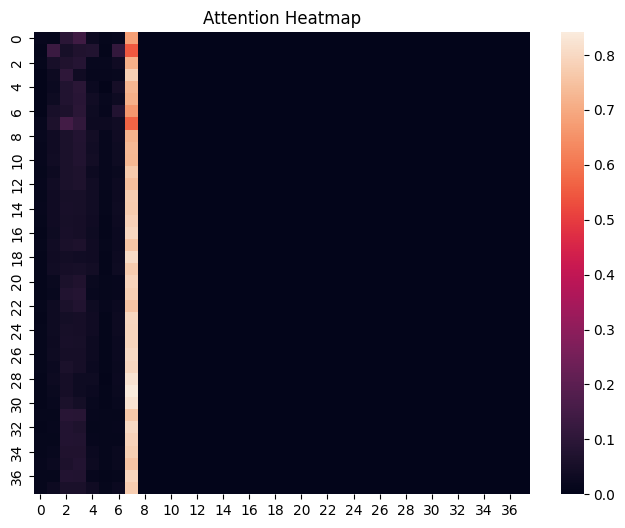

In [15]:
attention = attentions[-1][0][0].detach().numpy()

plt.figure(figsize=(8,6))
sns.heatmap(attention)
plt.title("Attention Heatmap")
plt.show()